## Importing libraries

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Loading Datasets

In [2]:
nhs = pd.read_csv("nhstalkingtherapies_month_feb_2026_activity_performance.csv")

imd = pd.read_csv("File_1_IoD2025 Index of Multiple Deprivation.csv")

lookup = pd.read_csv("LSOA_(2021)_to_SICBL_to_ICB_to_LAD_(April_2023)_Lookup_in_EN.csv")

icb_map = gpd.read_file("ICB_APR_2023_EN_BGC.shp")


## Exploring datasets


In [3]:
nhs.head()

,REPORTING_PERIOD_START,REPORTING_PERIOD_END,GROUP_TYPE,ORG_CODE1,ORG_NAME1,ORG_CODE2,ORG_NAME2,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE_SUPPRESSED
0,2026-02-01,2026-02-28,England,all,all SubICBs,all,all Providers,M001,Count_ReferralsReceived,151810
1,2026-02-01,2026-02-28,England,all,all SubICBs,all,all Providers,M002,Count_SelfReferrals,103623
2,2026-02-01,2026-02-28,England,all,all SubICBs,all,all Providers,M003,Count_GPReferrals,13041
3,2026-02-01,2026-02-28,England,all,all SubICBs,all,all Providers,M004,Count_HealthVisitorReferrals,445
4,2026-02-01,2026-02-28,England,all,all SubICBs,all,all Providers,M005,Count_OtherPrimaryCareReferrals,5750


In [4]:
imd.head()

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8
3,E01000005,City of London 001E,E09000001,City of London,14807,5
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4


In [5]:
lookup.head()

,LSOA21CD,LSOA21NM,SICBL23CD,SICBL23CDH,SICBL23NM,ICB23CD,ICB23CDH,ICB23NM,LAD23CD,LAD23NM,ObjectId
0,E01011954,Hartlepool 001A,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E06000001,Hartlepool,1
1,E01011969,Hartlepool 001B,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E06000001,Hartlepool,2
2,E01011970,Hartlepool 001C,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E06000001,Hartlepool,3
3,E01011971,Hartlepool 001D,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E06000001,Hartlepool,4
4,E01033465,Hartlepool 001F,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E06000001,Hartlepool,5


In [6]:
icb_map[['ICB23CD','ICB23NM']].head()

,ICB23CD,ICB23NM
0,E54000008,NHS Cheshire and Merseyside Integrated Care Board
1,E54000010,NHS Staffordshire and Stoke-on-Trent Integrate...
2,E54000011,"NHS Shropshire, Telford and Wrekin Integrated ..."
3,E54000013,NHS Lincolnshire Integrated Care Board
4,E54000015,"NHS Leicester, Leicestershire and Rutland Inte..."


## Filtering NHS Data to SubICB level


In [7]:
nhs_subicb = nhs[nhs['GROUP_TYPE'] == 'SubICB'].copy()
print(f"SubICB rows: {len(nhs_subicb):,}")
print(f"Unique Sub-ICBs: {nhs_subicb['ORG_CODE1'].nunique()}")

SubICB rows: 24,521
Unique Sub-ICBs: 113


## Preparing NHS data for Spatial Analysis

In [8]:
nhs_subicb['MEASURE_VALUE_SUPPRESSED'] = pd.to_numeric(
    nhs_subicb['MEASURE_VALUE_SUPPRESSED'], errors='coerce')

code_to_icb = (lookup[['SICBL23CDH', 'ICB23NM']].drop_duplicates().rename(columns={'SICBL23CDH': 'ORG_CODE1'}))

nhs_sub = nhs_subicb.merge(code_to_icb, on='ORG_CODE1', how='left')
print(f"Rows matched to ICB: {nhs_sub['ICB23NM'].notna().sum():,} / {len(nhs_sub):,}")

metrics = {
    'Count_ReferralsReceived'    : ('Referrals',          'sum'),
    'Count_AccessingServices'    : ('Accessing_Services', 'sum'),
    'Percentage_ReliableRecovery': ('Recovery_Rate',      'mean'),
    'Mean_WaitAccessingServices' : ('Mean_Wait_Days',     'mean'),
    'Count_WaitingForAssessmentOver90days': ('Waiting_Over90', 'sum'),}

icb_dfs = {}
for measure, (col_name, agg) in metrics.items():
    sub = nhs_sub[nhs_sub['MEASURE_NAME'] == measure]
    agg_df = sub.groupby('ICB23NM')['MEASURE_VALUE_SUPPRESSED'].agg(agg).reset_index()
    agg_df.columns = ['ICB23NM', col_name]
    icb_dfs[col_name] = agg_df

service = icb_dfs['Referrals']
for key in ['Accessing_Services', 'Recovery_Rate', 'Mean_Wait_Days', 'Waiting_Over90']:
    service = service.merge(icb_dfs[key], on='ICB23NM', how='outer')

service['Access_Rate'] = (service['Accessing_Services'] / service['Referrals'] * 100).round(2)

print(f"\nService table: {len(service)} ICBs")
service.head()

Rows matched to ICB: 23,002 / 24,521

Service table: 42 ICBs


,ICB23NM,Referrals,Accessing_Services,Recovery_Rate,Mean_Wait_Days,Waiting_Over90,Access_Rate
0,"NHS Bath and North East Somerset, Swindon and ...",1965.0,1350.0,46.0,11.7,20.0,68.70
1,"NHS Bedfordshire, Luton and Milton Keynes Inte...",2640.0,1390.0,47.0,35.3,265.0,52.65
2,NHS Birmingham and Solihull Integrated Care Board,4340.0,2645.0,48.0,19.7,400.0,60.94
3,NHS Black Country Integrated Care Board,3025.0,1740.0,44.0,49.2,1115.0,57.52
4,"NHS Bristol, North Somerset and South Gloucest...",2255.0,1205.0,50.0,32.2,20.0,53.44


## Preparing and Standardising IMD Deprivation Data

In [9]:
imd = imd.rename(columns={
    'LSOA code (2021)': 'LSOA21CD',
    'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)': 'IMD_Rank',
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)': 'IMD_Decile',})

n = len(imd)
imd['IMD_Score'] = ((n + 1 - imd['IMD_Rank']) / n * 100).round(4)

imd = imd[['LSOA21CD', 'IMD_Score', 'IMD_Rank', 'IMD_Decile']]
print(f"IMD LSOAs: {len(imd):,}")
print(f"IMD Score range: {imd['IMD_Score'].min():.2f} (least deprived) – {imd['IMD_Score'].max():.2f} (most deprived)")
imd.head()

IMD LSOAs: 33,755
IMD Score range: 0.00 (least deprived) – 100.00 (most deprived)


,LSOA21CD,IMD_Score,IMD_Rank,IMD_Decile
0,E01000001,21.4220,26525,8
1,E01000002,7.5633,31203,10
2,E01000003,23.2351,25913,8
3,E01000005,56.1369,14807,5
4,E01000006,67.6611,10917,4


## Spatial Joining

In [10]:
imd_lookup = imd.merge(
    lookup[['LSOA21CD', 'SICBL23CDH', 'ICB23CD', 'ICB23NM']],
    on='LSOA21CD',
    how='inner')
print(f"IMD + Lookup rows: {len(imd_lookup):,}")
print(f"ICBs covered: {imd_lookup['ICB23NM'].nunique()}")
imd_lookup.head()


IMD + Lookup rows: 33,755
ICBs covered: 42


,LSOA21CD,IMD_Score,IMD_Rank,IMD_Decile,SICBL23CDH,ICB23CD,ICB23NM
0,E01000001,21.4220,26525,8,A3A8R,E54000029,NHS North East London Integrated Care Board
1,E01000002,7.5633,31203,10,A3A8R,E54000029,NHS North East London Integrated Care Board
2,E01000003,23.2351,25913,8,A3A8R,E54000029,NHS North East London Integrated Care Board
3,E01000005,56.1369,14807,5,A3A8R,E54000029,NHS North East London Integrated Care Board
4,E01000006,67.6611,10917,4,A3A8R,E54000029,NHS North East London Integrated Care Board


## Aggregating Deprivation Data to ICB Level


In [11]:
imd_icb = imd_lookup.groupby('ICB23NM').agg(
    IMD_Score_Mean   = ('IMD_Score',  'mean'),
    IMD_Score_Median = ('IMD_Score',  'median'),
    IMD_Decile_Mean  = ('IMD_Decile', 'mean'),
    n_LSOAs          = ('LSOA21CD',   'count'),
).reset_index().round(4)

print(f"ICB-level IMD table: {len(imd_icb)} ICBs")
imd_icb.head()

ICB-level IMD table: 42 ICBs


,ICB23NM,IMD_Score_Mean,IMD_Score_Median,IMD_Decile_Mean,n_LSOAs
0,"NHS Bath and North East Somerset, Swindon and ...",36.1567,31.6723,6.8524,569
1,"NHS Bedfordshire, Luton and Milton Keynes Inte...",46.4414,42.8885,5.8552,587
2,NHS Birmingham and Solihull Integrated Care Board,67.4908,78.5247,3.7680,793
3,NHS Black Country Integrated Care Board,64.4896,75.4111,4.0443,723
4,"NHS Bristol, North Somerset and South Gloucest...",40.8421,36.5812,6.3838,581


In [12]:
print(imd_icb.nlargest(5, 'IMD_Score_Mean')[['ICB23NM','IMD_Score_Mean','IMD_Decile_Mean']].to_string(index=False))

                                          ICB23NM  IMD_Score_Mean  IMD_Decile_Mean
NHS Birmingham and Solihull Integrated Care Board         67.4908           3.7680
          NHS Black Country Integrated Care Board         64.4896           4.0443
      NHS North East London Integrated Care Board         62.8046           4.2217
        NHS South Yorkshire Integrated Care Board         61.0588           4.4209
   NHS North Central London Integrated Care Board         60.1696           4.4715


## Combining Mental Health Service Data with Deprivation Indicators



In [13]:
final = service.merge(imd_icb, on='ICB23NM', how='inner')
final[['ICB23NM','Referrals','Access_Rate','Recovery_Rate','IMD_Score_Mean']].head()

,ICB23NM,Referrals,Access_Rate,Recovery_Rate,IMD_Score_Mean
0,"NHS Bath and North East Somerset, Swindon and ...",1965.0,68.70,46.0,36.1567
1,"NHS Bedfordshire, Luton and Milton Keynes Inte...",2640.0,52.65,47.0,46.4414
2,NHS Birmingham and Solihull Integrated Care Board,4340.0,60.94,48.0,67.4908
3,NHS Black Country Integrated Care Board,3025.0,57.52,44.0,64.4896
4,"NHS Bristol, North Somerset and South Gloucest...",2255.0,53.44,50.0,40.8421


## Identifying High Need And Low Service Areas

In [14]:
high_need    = final['IMD_Score_Mean']  >= final['IMD_Score_Mean'].quantile(0.75)

low_referrals = final['Referrals']      <= final['Referrals'].quantile(0.25)
low_access    = final['Access_Rate']    <= final['Access_Rate'].quantile(0.25)
low_recovery  = final['Recovery_Rate']  <= final['Recovery_Rate'].quantile(0.25)

final['High_Need']   = high_need
final['Low_Service'] = low_referrals | low_access | low_recovery
final['underserved'] = high_need & final['Low_Service']

def norm(s, invert=False):
    mn, mx = s.min(), s.max()
    n = (s - mn) / (mx - mn) * 100 if mx != mn else pd.Series(50.0, index=s.index)
    return (100 - n) if invert else n

final['Score_Deprivation'] = norm(final['IMD_Score_Mean'])
final['Score_Low_Access']  = norm(final['Access_Rate'],   invert=True)
final['Score_Low_Recovery']= norm(final['Recovery_Rate'], invert=True)
final['Score_High_Wait']   = norm(final['Mean_Wait_Days'])
final['Unmet_Need_Score']  = (
    0.35 * final['Score_Deprivation'] +
    0.30 * final['Score_Low_Access']  +
    0.20 * final['Score_Low_Recovery']+
    0.15 * final['Score_High_Wait']
).round(2)

n_underserved = final['underserved'].sum()
print(f" Underserved ICBs identified: {n_underserved} out of {len(final)}")
print(" HIGH-NEED / LOW-SERVICE ICBs:")
cols = ['ICB23NM','IMD_Score_Mean','Referrals','Access_Rate','Recovery_Rate','Mean_Wait_Days','Unmet_Need_Score']
print(final[final['underserved']][cols].sort_values('Unmet_Need_Score', ascending=False).to_string(index=False))

 Underserved ICBs identified: 7 out of 42
 HIGH-NEED / LOW-SERVICE ICBs:
                                                   ICB23NM  IMD_Score_Mean  Referrals  Access_Rate  Recovery_Rate  Mean_Wait_Days  Unmet_Need_Score
              NHS Greater Manchester Integrated Care Board         60.1235    12210.0        49.51          42.90           38.98             74.35
                   NHS Black Country Integrated Care Board         64.4896     3025.0        57.52          44.00           49.20             73.44
               NHS North East London Integrated Care Board         62.8046     5440.0        55.33          49.00           32.50             62.70
            NHS North Central London Integrated Care Board         60.1696     4120.0        56.43          46.00           25.90             62.50
               NHS North West London Integrated Care Board         57.6900     6790.0        54.20          45.00           17.60             61.44
    NHS Lancashire and South Cumbria In

## Preparing Spatial Boundary Data for Mapping




In [15]:
icb_map_bng = icb_map.to_crs('EPSG:27700')
geo_final = icb_map_bng.merge(final, on='ICB23NM', how='left')
print(f"Spatial dataframe: {len(geo_final)} ICBs")
print(f"Underserved ICBs in map: {geo_final['underserved'].sum()}")
geo_final[['ICB23NM','IMD_Score_Mean','Access_Rate','underserved']].head()

Spatial dataframe: 42 ICBs
Underserved ICBs in map: 7


,ICB23NM,IMD_Score_Mean,Access_Rate,underserved
0,NHS Cheshire and Merseyside Integrated Care Board,53.5083,62.79,False
1,NHS Staffordshire and Stoke-on-Trent Integrate...,48.0824,60.50,False
2,"NHS Shropshire, Telford and Wrekin Integrated ...",50.7043,40.74,False
3,NHS Lincolnshire Integrated Care Board,52.9343,57.99,False
4,"NHS Leicester, Leicestershire and Rutland Inte...",45.7176,65.54,False


## Visualising Deprivation Levels Across England


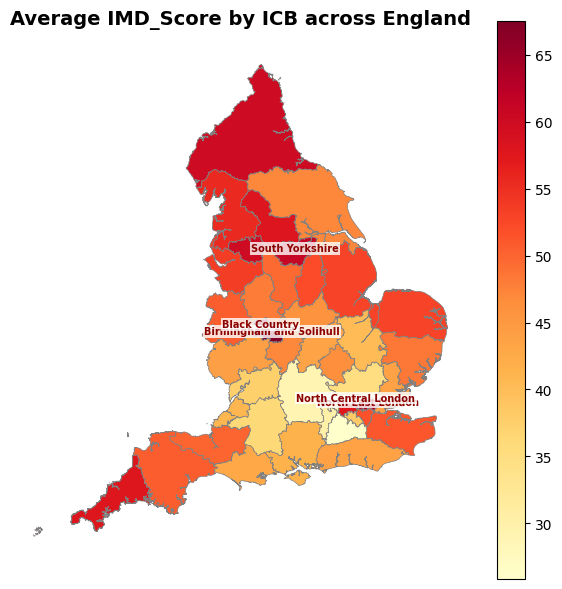

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
geo_final.plot(ax=ax,column='IMD_Score_Mean',cmap='YlOrRd',linewidth=0.5,edgecolor='gray',legend=True)
for _, row in geo_final.nlargest(5, 'IMD_Score_Mean').iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    name = (row['ICB23NM'].replace('NHS ', '').replace(' Integrated Care Board', '').strip())
    ax.annotate(name,xy=(cx, cy),fontsize=7,color='darkred',ha='center',fontweight='bold',bbox=dict(facecolor='white',alpha=0.8,edgecolor='none',pad=1))
ax.set_title('Average IMD_Score by ICB across England',fontsize=14,fontweight='bold',pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## Visualising Mental Health Service Access Across England


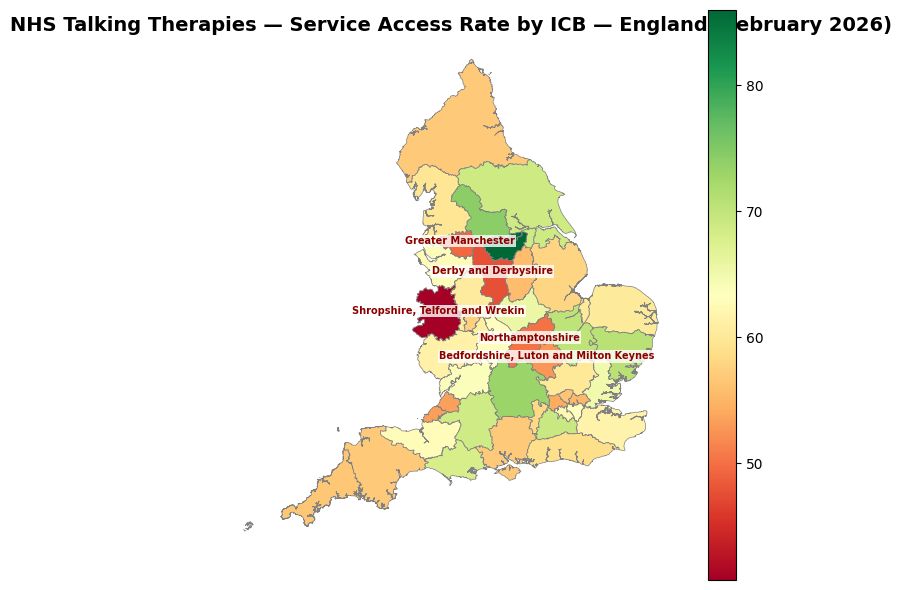

In [17]:
fig, ax = plt.subplots(figsize=(6,6))
geo_final.plot(ax=ax,column='Access_Rate',cmap='RdYlGn',linewidth=0.5,edgecolor='gray',legend=True)
for _, row in geo_final.nsmallest(5, 'Access_Rate').iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    name = (row['ICB23NM'].replace('NHS ', '').replace(' Integrated Care Board', '').strip())
    ax.annotate(name,xy=(cx, cy),fontsize=7,color='darkred',ha='center',fontweight='bold',bbox=dict(facecolor='white',alpha=0.8,edgecolor='none',pad=1))
ax.set_title('NHS Talking Therapies — Service Access Rate by ICB — England (February 2026)',fontsize=14,fontweight='bold',pad=1)
ax.axis('off')
plt.tight_layout()
plt.show()

## Identifying High-Need Low-Service Areas


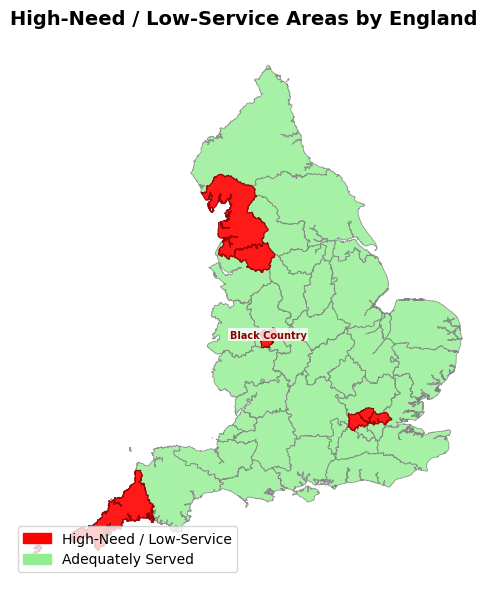

In [18]:
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(6, 6))
geo_final[geo_final['underserved'] == False].plot(ax=ax,color='lightgreen',edgecolor='gray',linewidth=0.6,alpha=0.8)
geo_final[geo_final['underserved'] == True].plot(ax=ax,color='red',edgecolor='darkred',linewidth=0.8,alpha=0.9)
for _, row in geo_final[geo_final['underserved'] == True].iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    name = (row['ICB23NM'].replace('NHS ', '').replace(' Integrated Care Board', '').strip())
ax.annotate(name,xy=(cx, cy),fontsize=7,color='darkred',fontweight='bold',ha='center',bbox=dict(facecolor='white', alpha=0.8,edgecolor='none',pad=1))
handles = [
    mpatches.Patch(color='red', label='High-Need / Low-Service'),
    mpatches.Patch(color='lightgreen', label='Adequately Served')]
ax.legend(handles=handles, loc='lower left')
ax.set_title('High-Need / Low-Service Areas by England ',fontsize=14,fontweight='bold',pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

In [19]:
print("High-Need / Low-Service ICBs")
priority = final[final['underserved'] == True] \
    .sort_values('Unmet_Need_Score', ascending=False)
summary = priority[[
    'ICB23NM',
    'IMD_Score_Mean',
    'Access_Rate',
    'Recovery_Rate',
    'Mean_Wait_Days',
    'Unmet_Need_Score'
]].round(1)

summary.columns = [
    'ICB Name',
    'IMD Score',
    'Access Rate (%)',
    'Recovery Rate (%)',
    'Average Wait (Days)',
    'Unmet Need Score'
]

print(summary.to_string(index=False))
print("\nNational Comparisons")
print(f"Average England access rate   : {final['Access_Rate'].mean():.1f}%")
print(f"Average England recovery rate : {final['Recovery_Rate'].mean():.1f}%")
print(f"Average England waiting time  : {final['Mean_Wait_Days'].mean():.1f} days")
print(f"\nPriority ICB average access rate   : {priority['Access_Rate'].mean():.1f}%")
print(f"Priority ICB average recovery rate : {priority['Recovery_Rate'].mean():.1f}%")

final.to_csv('final_icb_analysis.csv', index=False)


High-Need / Low-Service ICBs
                                                  ICB Name  IMD Score  Access Rate (%)  Recovery Rate (%)  Average Wait (Days)  Unmet Need Score
              NHS Greater Manchester Integrated Care Board       60.1             49.5               42.9                 39.0              74.4
                   NHS Black Country Integrated Care Board       64.5             57.5               44.0                 49.2              73.4
               NHS North East London Integrated Care Board       62.8             55.3               49.0                 32.5              62.7
            NHS North Central London Integrated Care Board       60.2             56.4               46.0                 25.9              62.5
               NHS North West London Integrated Care Board       57.7             54.2               45.0                 17.6              61.4
    NHS Lancashire and South Cumbria Integrated Care Board       55.6             59.7               